# Project 8: Forward Volatility from the SOFR Cap Market

**Data**: `project_cap_vol_ts.xlsx`, `cap_curves_2025-06-30.xlsx`, `ref_rates.xlsx`


## Project Statement

Strip forward volatilities from the SOFR cap market over 2022–2025 and test whether the forward vol curve predicts future spot vol—a Fama–Bliss analog for the volatility term structure. Characterize the resulting volatility term premium and analyze how it varies across the hiking, pause, and easing regimes of the Fed's policy cycle.


## Context

### From Flat Vol to Forward Vol

In the cap market, prices are quoted in **flat volatility**—a single implied vol that prices all caplets in a given cap, regardless of their individual maturities. This is a quoting convention, analogous to yield-to-maturity for bonds. Just as bond pricing requires spot rates (not YTM), derivative pricing requires **forward volatilities** that assign each caplet its own vol consistent with its maturity.

Extracting forward vols from flat vols is a **bootstrap** problem: given a sequence of cap prices at maturities $T_1 < T_2 < \ldots$, strip out the incremental caplet prices and invert Black's formula to recover the forward vol at each tenor. Exercise 7.1 walks through this on a single date.

### The Vol Curve as a Forecast

The forward vol curve has a natural interpretation as a forecast of future rate volatility. The $\tau$-year forward caplet vol represents the market's expectation (plus any risk premium) for rate volatility during the quarter ending at $\tau$.

A natural question, then, is whether forward vol is an unbiased predictor of future spot vol. This is the **Fama–Bliss analog for volatility**: just as forward rates predict future spot rates (but with a term premium), forward vols may predict future spot vols—but with a **volatility term premium**.

### Normal vs Black Vol

Bloomberg quotes cap vols in **normal** (Bachelier) terms, reported in basis points. For comparing forward vol across different rate levels and to realized rate volatility, normal vol is the appropriate measure:

$$\sigma_{\text{normal}} \approx \sigma_{\text{Black}} \times f$$

where $f$ is the forward rate. This approximation is exact at-the-money.

### The 2022–2025 Rate Cycle

This project covers a period of extraordinary rate volatility:

| Period | Regime | SOFR Range | Implication |
|--------|--------|------------|-------------|
| Mar 2022 – Jul 2023 | Aggressive hiking | 0.05% → 5.30% | High realized vol, uncertain terminal rate |
| Aug 2023 – Aug 2024 | Pause | ~5.30% | Low realized vol, high implied vol (when does the cut come?) |
| Sep 2024 – Dec 2025 | Easing | 5.30% → ~3.75% | Moderate realized vol, declining implied vol |

These three regimes create a natural laboratory for studying how the volatility term premium behaves under different policy conditions.


## Resources

### Course Materials

- **Discussion 7.1**: Forward Volatility and Caps — flat vs forward vol, stripping mechanics, Black's formula for caplets
- **Exercise 7.1**: Stripping Caps — single-date bootstrap of forward vols from flat vols (the starting point for Q1)
- **Discussion 5.1**: SOFR Swap Curve — discount factor construction needed for cap pricing

### External Reading

- CME Group: [Interest Rate Volatility](https://www.cmegroup.com/education/courses/introduction-to-interest-rate-options.html) — market structure for rate options
- NY Fed: [SOFR](https://www.newyorkfed.org/markets/reference-rates/sofr) — rate calculation methodology
- Federal Reserve: [FOMC Calendars](https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm) — policy dates for regime classification

### Data Files

| File | Description | Frequency | Date Range |
|------|-------------|-----------|------------|
| `project_cap_vol_ts.xlsx` | Cap flat vols (normal, bp) + SOFR swap rates | Daily | 2022–2025 |
| `cap_curves_2025-06-30.xlsx` | Processed rate/vol curves for validation | Single date | 2025-06-30 |
| `ref_rates.xlsx` | Daily SOFR, Fed Funds, T-bill rates | Daily | 2018–2025 |

**Data location**: All files are in the `../data/` directory relative to this notebook.

#### Cap Vol Data Details

The `project_cap_vol_ts.xlsx` file contains two sheets:
- **`cap`**: ATM normal vol quotes for 1Y–10Y SOFR caps (Bloomberg `USCNSQ{1-10} SMKO Curncy`). Vols are in basis points.
- **`sofr`**: SOFR swap rates at monthly/quarterly/annual tenors up to 10Y. Rates are in percent, annually compounded.

The first row of each sheet contains maturity metadata (in years). Subsequent rows are daily observations.

### Additional Data Sources
- **FRED**: Daily SOFR rate for realized vol computation (already in `ref_rates.xlsx`)
- **Bloomberg** (optional): If you have access, you can pull additional cap maturities or OTM strikes via the `VCUB` screen


## Data Preview

The following code loads the data and creates initial visualizations.


In [217]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import norm
from scipy.optimize import brentq
import statsmodels.api as sm

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', 15)

DATA_PATH = Path('./data')

In [218]:
# Load cap vol time series
cap_raw = pd.read_excel(DATA_PATH / 'project_cap_vol_ts.xlsx', sheet_name='cap', index_col=0)
cap_maturities = cap_raw.loc['maturity'].astype(float)
cap_data = cap_raw.drop(index='maturity').astype(float)
cap_data.index = pd.to_datetime(cap_data.index)

# Round maturities to nearest year (BB reports e.g. 0.999 instead of 1.0)
cap_data.columns = (4 * cap_maturities.values).round(0) / 4
cap_data.columns.name = 'maturity'
cap_data = cap_data.T.drop_duplicates().T

print(f'Cap data: {cap_data.shape[0]} days, maturities: {list(cap_data.columns)}')
print(f'Date range: {cap_data.index.min().date()} to {cap_data.index.max().date()}')
cap_data.tail(3)

Cap data: 989 days, maturities: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
Date range: 2022-03-17 to 2025-12-31


maturity,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0
date,,,,,,,,,,
2025-12-29,52.2,66.8,73.5,77.3,79.6,81.2,82.1,82.8,83.3,83.7
2025-12-30,50.9,66.1,72.9,76.7,78.9,80.4,81.3,81.9,82.4,82.8
2025-12-31,50.8,65.9,72.9,76.7,78.9,80.4,81.4,82.0,NaN,NaN


In [219]:
# Load SOFR swap time series
sofr_raw = pd.read_excel(DATA_PATH / 'project_cap_vol_ts.xlsx', sheet_name='sofr', index_col=0)
sofr_maturities = sofr_raw.loc['maturity'].astype(float)
sofr_data = sofr_raw.drop(index='maturity').astype(float)
sofr_data.index = pd.to_datetime(sofr_data.index)
sofr_data.columns = (12 * sofr_maturities.values).round(0) / 12
sofr_data.columns.name = 'maturity'
sofr_data = sofr_data.T.drop_duplicates().T
sofr_data = sofr_data / 100  # percent to decimal

print(f'SOFR swap data: {sofr_data.shape[0]} days, {sofr_data.shape[1]} tenors')
sofr_data.tail(3)

SOFR swap data: 1033 days, 21 tenors


maturity,0.25,0.50,0.75,1.00,1.25,1.50,1.75,...,4.50,5.00,6.00,7.00,8.00,9.00,10.00
date,,,,,,,,,,,,,,,
2025-12-29,0.036670,0.035886,0.034989,0.034239,0.033538,0.033140,0.032940,...,0.033746,0.034104,0.034800,0.035506,0.036177,0.036827,0.037457
2025-12-30,0.036567,0.035805,0.034931,0.034190,0.033510,0.033115,0.032919,...,0.033849,0.034214,0.034927,0.035648,0.036330,0.036989,0.037621
2025-12-31,0.036517,0.035796,0.034961,0.034270,0.033631,0.033285,0.033140,...,0.034226,0.034638,0.035355,0.036068,0.036735,0.037388,0.038023


In [220]:
# Load reference rates (SOFR daily)
ref_rates = pd.read_excel(DATA_PATH / 'ref_rates.xlsx', sheet_name='data')
ref_rates['date'] = pd.to_datetime(ref_rates['date'])
ref_rates = ref_rates.set_index('date').sort_index()

sofr_daily = ref_rates['SOFR'].dropna() / 100
print(f'SOFR daily: {len(sofr_daily)} observations, {sofr_daily.index.min().date()} to {sofr_daily.index.max().date()}')

SOFR daily: 1935 observations, 2018-04-03 to 2025-12-31


In [221]:
# Load validation curves (single-date, fully processed)
curves_validation = pd.read_excel(
    DATA_PATH / 'cap_curves_2025-06-30.xlsx',
    sheet_name='rate curves 2025-06-30'
).set_index('tenor')

print(f'Validation curves: {curves_validation.shape}')
display(curves_validation.head())

Validation curves: (40, 6)


,swap rates,spot rates,discounts,forwards,flat vols,fwd vols
tenor,,,,,,
0.25,0.042353,0.042353,0.989523,NaN,NaN,NaN
0.50,0.040859,0.040852,0.979883,0.039351,0.156842,0.156842
0.75,0.039391,0.039372,0.971043,0.036414,0.180709,0.201708
1.00,0.038115,0.038083,0.962807,0.034217,0.204576,0.240464
1.25,0.036704,0.036653,0.955417,0.030938,0.242127,0.328341


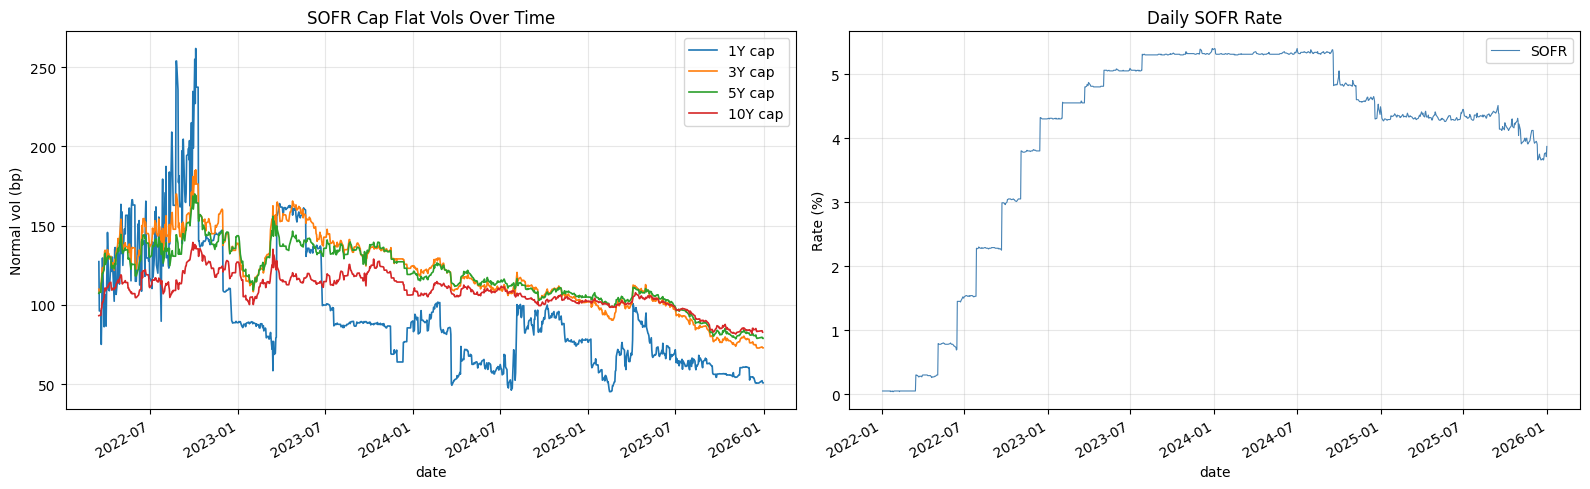

In [222]:
# Figure 1: Cap flat vols over time
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
for mat in [1.0, 3.0, 5.0, 10.0]:
    if mat in cap_data.columns:
        cap_data[mat].dropna().plot(ax = ax, label = f'{int(mat)}Y cap', linewidth = 1.2)
ax.set_ylabel('Normal vol (bp)')
ax.set_title('SOFR Cap Flat Vols Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

# SOFR rate for context
ax = axes[1]
sofr_rate_pct = sofr_daily.loc['2022':] * 100
sofr_rate_pct.plot(ax=ax, linewidth = 0.8, color = 'steelblue', label = 'SOFR')
ax.set_ylabel('Rate (%)')
ax.set_title('Daily SOFR Rate')
ax.legend()
ax.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

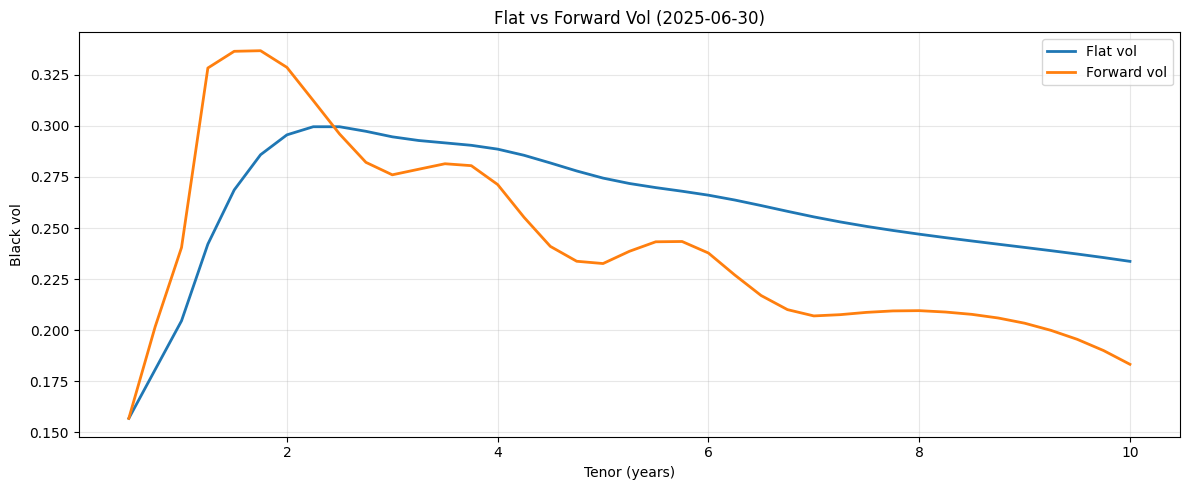

In [223]:
# Figure 2: Flat vs forward vol on the validation date
fig, ax = plt.subplots()
curves_validation['flat vols'].dropna().plot(ax = ax, label = 'Flat vol', linewidth = 2)
curves_validation['fwd vols'].dropna().plot(ax = ax, label = 'Forward vol', linewidth = 2)
ax.set_xlabel('Tenor (years)')
ax.set_ylabel('Black vol')
ax.set_title('Flat vs Forward Vol (2025-06-30)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Key Formulas

Refer to **Discussion 7.1** and **Exercise 7.1** for detailed derivations.

### Black's Formula for a Caplet

$$P_{\text{caplet}} = \frac{100}{4} \cdot Z_\tau \left[ f_\tau \mathcal{N}(d_1) - K \mathcal{N}(d_2) \right]$$

where $d_1 = \frac{\ln(f_\tau/K) + \frac{\sigma^2}{2}(\tau - 0.25)}{\sigma\sqrt{\tau - 0.25}}$ and $d_2 = d_1 - \sigma\sqrt{\tau - 0.25}$.

### Cap Price from Flat Vol

A cap with maturity $T$ and flat vol $\sigma_{\text{flat},T}$:

$$P_{\text{cap}}(T) = \sum_{\tau=0.5}^{T} P_{\text{caplet}}(\tau, \sigma_{\text{flat},T}, K=s_T)$$

where $s_T$ is the ATM swap rate.

### Forward Vol Bootstrap

The caplet price at $\tau$ is:
$$P_{\text{caplet}}(\tau) = P_{\text{cap}}(\tau) - P_{\text{cap}}(\tau - 0.25)$$

Invert Black's formula to find $\sigma_{\text{fwd},\tau}$.

### Normal Vol Conversion (ATM)

$$\sigma_{\text{normal}} = \sigma_{\text{Black}} \times f$$

### Fama–Bliss Analog for Volatility

$$\sigma_{\text{spot}}(t{+}h, \delta) = \alpha + \beta \cdot \sigma_{\text{fwd}}(t, \tau) + \varepsilon_t$$

where $h = \tau - \delta$ is the forecast horizon and $\delta$ is the spot caplet tenor.

### Volatility Term Premium

$$\text{VTP}_t(\tau) = \sigma_{\text{fwd}}(t, \tau) - \sigma_{\text{spot}}(t{+}h, \delta)$$

### Realized Vol

$$\sigma_{\text{realized}, t \to t+k} = \text{std}(\Delta r_{\text{SOFR}}) \times \sqrt{252}$$

computed over daily SOFR rate changes in the window $[t, t+k]$.


## Questions

Address the following questions in your analysis.


### Helper Functions

In [224]:
def normal_vol_to_black_vol(date, cap_data, sofr_data):
    """
    Select a single date from the time series
    Use that dates cap flat cols and SOFR swap rates
    convert bloomberg normal vols to black vols
    """
    cap_slice = cap_data.loc[date].dropna()
    sofr_slice = sofr_data.loc[date].dropna()

    cap_slice_bloomberg = cap_slice / 10000
    fwd_rates = sofr_slice.reindex(cap_slice_bloomberg.index).interpolate()
    black_vol = cap_slice_bloomberg / fwd_rates

    black_vol.name = "black_vol"

    display(pd.DataFrame({
        "normal_vol(bp)": cap_slice,
        "swap_rate": fwd_rates,
        "black_vol": black_vol
    }))
    return cap_slice, sofr_slice, black_vol

In [225]:
def get_market_slices(date, cap_data, sofr_data):
    """
    Extract one-date cap and swap slices.
    """
    cap_slice = cap_data.loc[date].dropna().astype(float)
    swap_slice = sofr_data.loc[date].dropna().astype(float)
    return cap_slice, swap_slice

In [226]:
def build_flat_vol_curve(cap_slice, swap_slice, quarterly_grid):
    """
    Convert annual cap normal vols (bp) to Black flat vols,
    then interpolate to the quarterly tenor grid.
    """
    normal_vol = cap_slice / 10000.0

    approx_atm_rates = (
        swap_slice.reindex(normal_vol.index)
        .interpolate(method = "linear", limit_direction = "both")
    )

    black_vol = normal_vol / approx_atm_rates

    flat_vols = (
        black_vol.reindex(quarterly_grid)
        .interpolate(method = "linear", limit_direction = "both")
    )

    flat_vols.loc[0.25] = np.nan
    flat_vols.name = "flat vols"
    return flat_vols

In [227]:
def build_quarterly_swap_curve(swap_slice, quarterly_grid):
    """
    Interpolate swap rates onto the quarterly tenor grid.
    """
    swap_q = (
        swap_slice.reindex(quarterly_grid)
        .interpolate(method = "linear", limit_direction = "both")
    )
    swap_q.name = "swap rates"
    return swap_q

In [228]:
def bootstrap_discount_forward_curve(swap_q, delta):
    """
    Vanilla par-swap bootstrap:
      swap rates -> discounts -> spot rates -> forward rates
    """
    tenor_grid = np.array(swap_q.index, dtype = float)

    discounts = pd.Series(index = swap_q.index, dtype = float)

    for j, T in enumerate(tenor_grid, start=1):
        S = swap_q.loc[T]

        if j == 1:
            discounts.loc[T] = 1 / (1 + S * delta)
        else:
            prev_times = tenor_grid[:j-1]
            discounts.loc[T] = (1 - S * delta * discounts.loc[prev_times].sum()) / (1 + S * delta)

    discounts.name = "discounts"

    spot_rates = pd.Series(index = swap_q.index, dtype = float)
    for T in tenor_grid:
        spot_rates.loc[T] = discounts.loc[T] ** (-1 / T) - 1
    spot_rates.name = "spot rates"

    forwards = pd.Series(index = swap_q.index, dtype = float)
    forwards.loc[tenor_grid[0]] = np.nan

    for j in range(1, len(tenor_grid)):
        T_prev = tenor_grid[j-1]
        T = tenor_grid[j]
        forwards.loc[T] = (discounts.loc[T_prev] / discounts.loc[T] - 1) / delta

    forwards.name = "forwards"

    return discounts, spot_rates, forwards

In [229]:
# Bootstrap forward vols from flat vols using the caplet stripping method
def black_caplet_price(F, K, sigma, tau, DF, delta, notional):

    if pd.isna(F) or pd.isna(K) or pd.isna(sigma) or pd.isna(DF):
        return np.nan

    option_expiry = tau - delta
    if option_expiry <= 0:
        return np.nan

    if sigma <= 0:
        return notional * delta * DF * max(F - K, 0.0)

    vol_sqrt_t = sigma * np.sqrt(option_expiry)
    if vol_sqrt_t <= 0:
        return notional * delta * DF * max(F - K, 0.0)

    d1 = (np.log(F / K) + 0.5 * sigma**2 * option_expiry) / vol_sqrt_t
    d2 = d1 - vol_sqrt_t

    return notional * delta * DF * (F * norm.cdf(d1) - K * norm.cdf(d2))

def implied_black_caplet_vol(price, F, K, tau, DF, delta, notional):
    
    if pd.isna(price) or pd.isna(F) or pd.isna(K) or pd.isna(tau) or pd.isna(DF):
        return np.nan

    option_expiry = tau - delta
    if option_expiry <= 0:
        return np.nan

    intrinsic = notional * delta * DF * max(F - K, 0.0)

    # tiny numerical tolerance around intrinsic
    if price <= intrinsic + 1e-12:
        return 0.0

    def objective(sigma):
        return black_caplet_price(F, K, sigma, tau, DF, delta = delta, notional = notional) - price

    try:
        return brentq(objective, 1e-8, 5.0)
    except ValueError:
        return np.nan



In [230]:
def price_caps_from_flat_vols(flat_vols, swap_q, discounts, forwards, delta, notional):
    """
    Price each T-maturity cap using:
      - flat vol sigma_flat(T)
      - ATM strike K = swap rate at T
      - sum of Black caplets up to T
    """
    tenor_grid = np.array(flat_vols.index, dtype = float)
    cap_prices = pd.Series(index=flat_vols.index, dtype=float)

    for T in tenor_grid:
        sigma_flat = flat_vols.loc[T]

        if T < 0.50 or pd.isna(sigma_flat):
            cap_prices.loc[T] = np.nan
            continue

        K = swap_q.loc[T]
        cap_val = 0.0

        caplet_payment_dates = tenor_grid[(tenor_grid >= 0.50) & (tenor_grid <= T)]

        for tau in caplet_payment_dates:
            F = forwards.loc[tau]
            DF = discounts.loc[tau]
            cap_val += black_caplet_price(F = F, K = K, sigma = sigma_flat, tau = tau, DF = DF, delta = delta, notional = notional)

        cap_prices.loc[T] = cap_val

    cap_prices.name = "cap prices"
    return cap_prices

In [231]:
def strip_caplet_prices(cap_prices, delta):
    """
    Strip caplet prices from adjacent cap prices:
      caplet(T) = cap(T) - cap(T-delta)
    """
    tenor_grid = np.array(cap_prices.index, dtype = float)
    caplet_prices = pd.Series(index=cap_prices.index, dtype = float)

    for T in tenor_grid:
        if T < 0.50 or pd.isna(cap_prices.loc[T]):
            caplet_prices.loc[T] = np.nan
        elif np.isclose(T, 0.50):
            caplet_prices.loc[T] = cap_prices.loc[T]
        else:
            prev_T = round(T - delta, 10)
            caplet_prices.loc[T] = cap_prices.loc[T] - cap_prices.loc[prev_T]

    caplet_prices.name = "caplet prices"
    return caplet_prices

In [232]:
def invert_caplet_prices_to_fwd_vols(caplet_prices, swap_q, discounts, forwards, delta):
    """
    Convert stripped caplet prices to Black forward caplet vols.
    """
    tenor_grid = np.array(caplet_prices.index, dtype = float)
    fwd_vols = pd.Series(index = caplet_prices.index, dtype = float)

    for tau in tenor_grid:
        if tau < 0.50 or pd.isna(caplet_prices.loc[tau]):
            fwd_vols.loc[tau] = np.nan
            continue

        F = forwards.loc[tau]
        DF = discounts.loc[tau]
        K = swap_q.loc[tau]
        price = caplet_prices.loc[tau]

        fwd_vols.loc[tau] = implied_black_caplet_vol(price = price, F = F, K = K, tau = tau, DF = DF, delta = delta, notional = notional)

    fwd_vols.name = "fwd vols"
    return fwd_vols

In [233]:
def strip_forward_vol_curve(date, cap_data, sofr_data, quarterly_grid, delta, notional):
    """
    Full one-date pipeline:
      market slices
      -> flat vols
      -> quarterly swap curve
      -> discounts/spots/forwards
      -> cap prices
      -> caplet prices
      -> forward vols
    """
    cap_slice, swap_slice = get_market_slices(date, cap_data, sofr_data)

    flat_vols = build_flat_vol_curve(cap_slice, swap_slice, quarterly_grid = quarterly_grid)
    swap_q = build_quarterly_swap_curve(swap_slice, quarterly_grid = quarterly_grid)

    discounts, spot_rates, forwards = bootstrap_discount_forward_curve(swap_q, delta = delta)

    cap_prices = price_caps_from_flat_vols(
        flat_vols = flat_vols,
        swap_q = swap_q,
        discounts = discounts,
        forwards = forwards,
        delta = delta,
        notional = notional
    )

    caplet_prices = strip_caplet_prices(cap_prices, delta = delta)

    fwd_vols = invert_caplet_prices_to_fwd_vols(
        caplet_prices = caplet_prices,
        swap_q = swap_q,
        discounts = discounts,
        forwards = forwards,
        delta = delta
    )

    curve = pd.DataFrame({
        "swap rates": swap_q,
        "spot rates": spot_rates,
        "discounts": discounts,
        "forwards": forwards,
        "flat vols": flat_vols,
        "cap prices": cap_prices,
        "caplet prices": caplet_prices,
        "fwd vols": fwd_vols
    })

    return curve

In [234]:
delta = 0.25
notional = 100
quarterly_grid = np.arange(0.25, 10.25, 0.25)
key_tenors = [0.5, 1.0, 2.0, 3.0, 5.0]

### Question 1: Cap Stripping Mechanics

**Replicate and extend E.7.1 using the provided time-series data.**

a) Select a single date from the time series. Using that date's cap flat vols and SOFR swap curve, build the full processing pipeline:
   - Convert Bloomberg normal vols (bp) to Black vols
   - Interpolate to a quarterly grid
   - Construct discount and forward curves
   - Bootstrap forward vols from flat vols

   Validate your pipeline against the processed `cap_curves_2025-06-30.xlsx` file.

In [235]:
Q1a_date = pd.Timestamp("2025-06-30")
curve_q1 = strip_forward_vol_curve(Q1a_date, cap_data, sofr_data, quarterly_grid = quarterly_grid, delta = delta, notional = notional)
display(curve_q1.head(12))

,swap rates,spot rates,discounts,forwards,flat vols,cap prices,caplet prices,fwd vols
maturity,,,,,,,,
0.25,0.043019,0.043718,0.989360,NaN,NaN,NaN,NaN,NaN
0.50,0.041467,0.042107,0.979589,0.039899,0.181032,0.019975,0.019975,0.181032
0.75,0.039991,0.040574,0.970611,0.036997,0.181032,0.054069,0.034094,0.243169
1.00,0.038667,0.039197,0.962282,0.034625,0.181032,0.100740,0.046671,0.285872
1.25,0.037205,0.037672,0.954827,0.031229,0.201241,0.179509,0.078769,0.429612
1.50,0.036121,0.036544,0.947586,0.030565,0.221450,0.274193,0.094684,0.435217
1.75,0.035409,0.035804,0.940296,0.031013,0.241660,0.386083,0.111890,0.419978
2.00,0.034903,0.035279,0.933008,0.031246,0.261869,0.518827,0.132744,0.428661
2.25,0.034435,0.034792,0.925935,0.030555,0.267887,0.639023,0.120196,0.384830


In [236]:
# Validte against provided curves
q1_compare = curve_q1[["swap rates", "spot rates", "discounts", "forwards", "flat vols", "fwd vols"]].copy()
q1_compare.index.name = "tenor"

common_index = q1_compare.index.intersection(curves_validation.index)
common_cols = q1_compare.columns.intersection(curves_validation.columns)

validation_compare = curves_validation.loc[common_index, common_cols].copy()
model_compare = q1_compare.loc[common_index, common_cols].copy()

abs_diff = model_compare - validation_compare

rel_diff = abs_diff / validation_compare

validation_summary = pd.DataFrame({
    "mean_abs_error": abs_diff.abs().mean(),
    "max_abs_error": abs_diff.abs().max(),
    "rmse": np.sqrt((abs_diff**2).mean()),
    "mean_rel_error": rel_diff.abs().mean(),
    "max_rel_error": rel_diff.abs().max()
}).sort_index()

display(validation_summary)

,mean_abs_error,max_abs_error,rmse,mean_rel_error,max_rel_error
discounts,0.001864,0.003501,0.002104,0.002364,0.005042
flat vols,0.022643,0.047192,0.025549,0.089585,0.175669
forwards,0.000506,0.000670,0.000518,0.013718,0.015995
fwd vols,0.026221,0.101271,0.040158,0.095129,0.308433
spot rates,0.000954,0.001365,0.000961,0.026962,0.032224
swap rates,0.000469,0.000666,0.000472,0.013270,0.015721


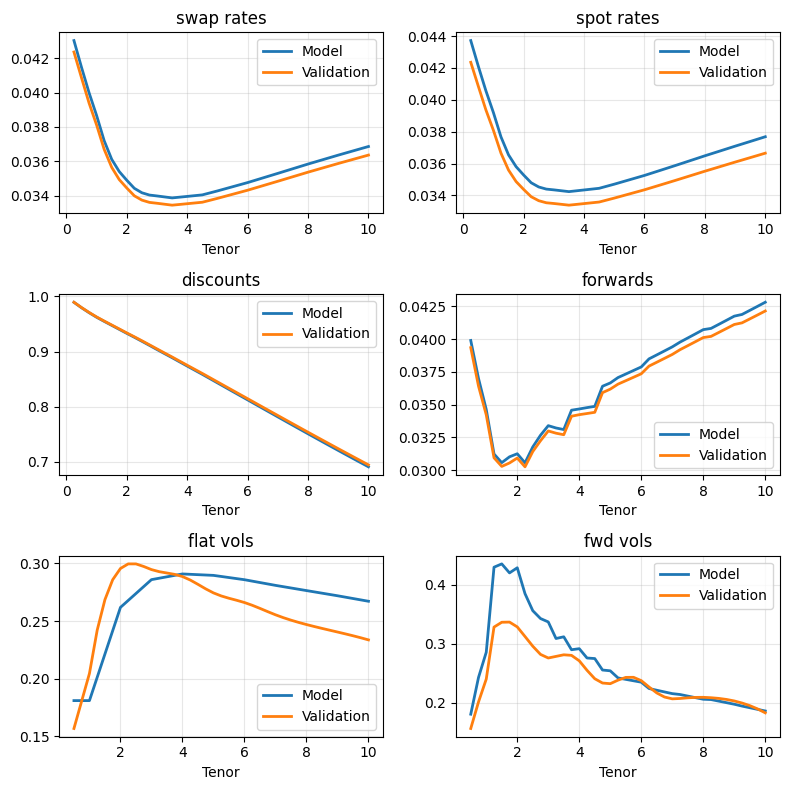

In [237]:
fig, axes = plt.subplots(3, 2, figsize=(8, 8))
axes = axes.flatten()

for ax, col in zip(axes, common_cols):
    model_compare[col].dropna().plot(ax = ax, linewidth = 2, label = "Model")
    validation_compare[col].dropna().plot(ax = ax, linewidth = 2, label = "Validation")
    ax.set_title(col)
    ax.set_xlabel("Tenor")
    ax.grid(True, alpha = 0.3)
    ax.legend()

plt.tight_layout()
plt.show()

b) Plot the flat vol and forward vol term structures side by side. The forward vol curve is typically **humped**: near-term vol reflects current policy uncertainty, while long-term vol reverts to a mean. Describe the shape you observe and explain why it looks that way given where the Fed was in its policy cycle on your chosen date.

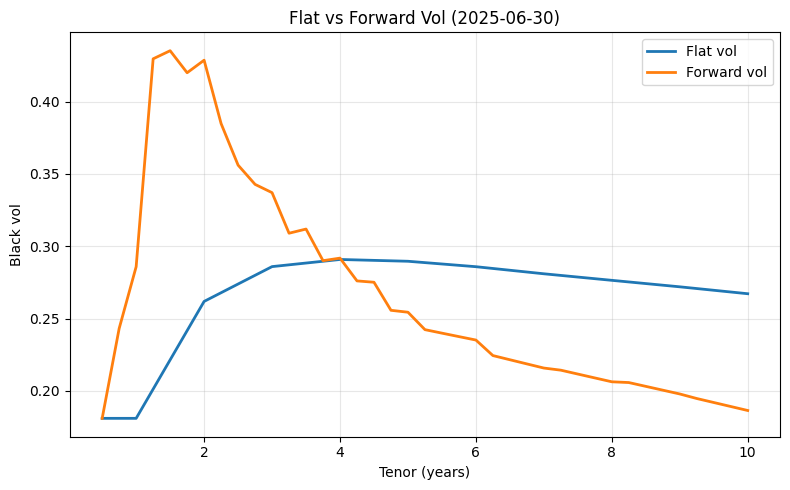

In [238]:
fig, ax = plt.subplots(figsize=(8, 5))

curve_q1["flat vols"].dropna().plot(ax = ax, linewidth = 2, label = "Flat vol")
curve_q1["fwd vols"].dropna().plot(ax = ax, linewidth = 2, label = "Forward vol")

ax.set_xlabel("Tenor (years)")
ax.set_ylabel("Black vol")
ax.set_title(f"Flat vs Forward Vol ({Q1a_date.date()})")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The forward vol curve spikes in the near term peaking around 4.3% in the 1-2 year tenors. During this regime, the SOFR range moved from 5.3% to 3.75% through the easing cycle, with moderate realized vol and declining implied vol, including three 25bps cuts toward the end of the cycle. Around June there was likely uncertainty about the timing and magnitude of additional cuts and then stabilization in the long run, this is reflected in the hump around shorter tenor vol and longer term vol decline.

The shape of the flat vol curve is also consisten with the fact that it represents an average vol over an entire maturity, while forward volatility is measured over specific intervals.

c) Repeat Q1b on 3–4 dates spanning the rate cycle (e.g., mid-2022, mid-2023, mid-2024, mid-2025). How does the shape of the forward vol curve change across regimes?

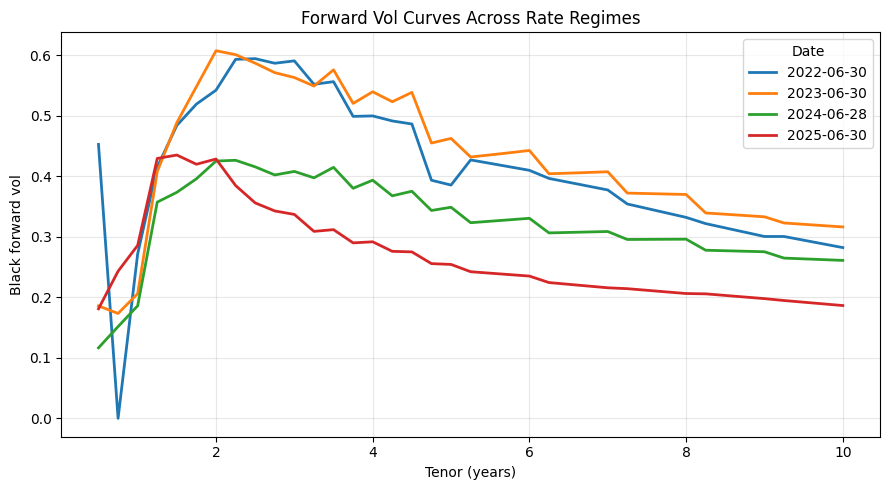

In [239]:
q1c_dates = [
    pd.Timestamp("2022-06-30"),  # Aggressive hiking cycle
    pd.Timestamp("2023-06-30"),  # late hiking / near peak
    pd.Timestamp("2024-06-28"),  # pause
    pd.Timestamp("2025-06-30"),  # easing
]

q1c_curves = {}

for d in q1c_dates:
    q1c_curves[d] = strip_forward_vol_curve(
        d,
        cap_data = cap_data,
        sofr_data = sofr_data,
        quarterly_grid = quarterly_grid,
        delta = delta,
        notional = notional
    )

# Forward vol curves across regimes
fig, ax = plt.subplots(figsize=(9, 5))

for d, curve in q1c_curves.items():
    curve["fwd vols"].dropna().plot(ax = ax, linewidth = 2, label = str(d.date()))

ax.set_xlabel("Tenor (years)")
ax.set_ylabel("Black forward vol")
ax.set_title("Forward Vol Curves Across Rate Regimes")
ax.legend(title="Date")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Across rate regimes the shape of the forward vol curve mainly changes in level, and also changes in shape. 2022 was the Aggressive hiking regime, there was high realized vol and uncertainty about the peak interest rate, thus the 2922 forward curve has a high level across all tenors relative to 2024 and 2025. In 2023, after the peak of aggressive hiking, there was a pause in rate changes but the forward vol curve is still elevated due to uncertainty about when rate cutes would begin. Policy uncertainity leads to hump in the earlier tenors for both years.

In 2024 and 2025 the level of the vol curve is much lower, there is still a hump in the shorter tenors, likely due to uncertainty about the rate and magnitude of the easing period, but the hump is concentrated in earlier tenors than in 2022-23. All four forward vol curves flatten out, reflecting a return to stbaility.

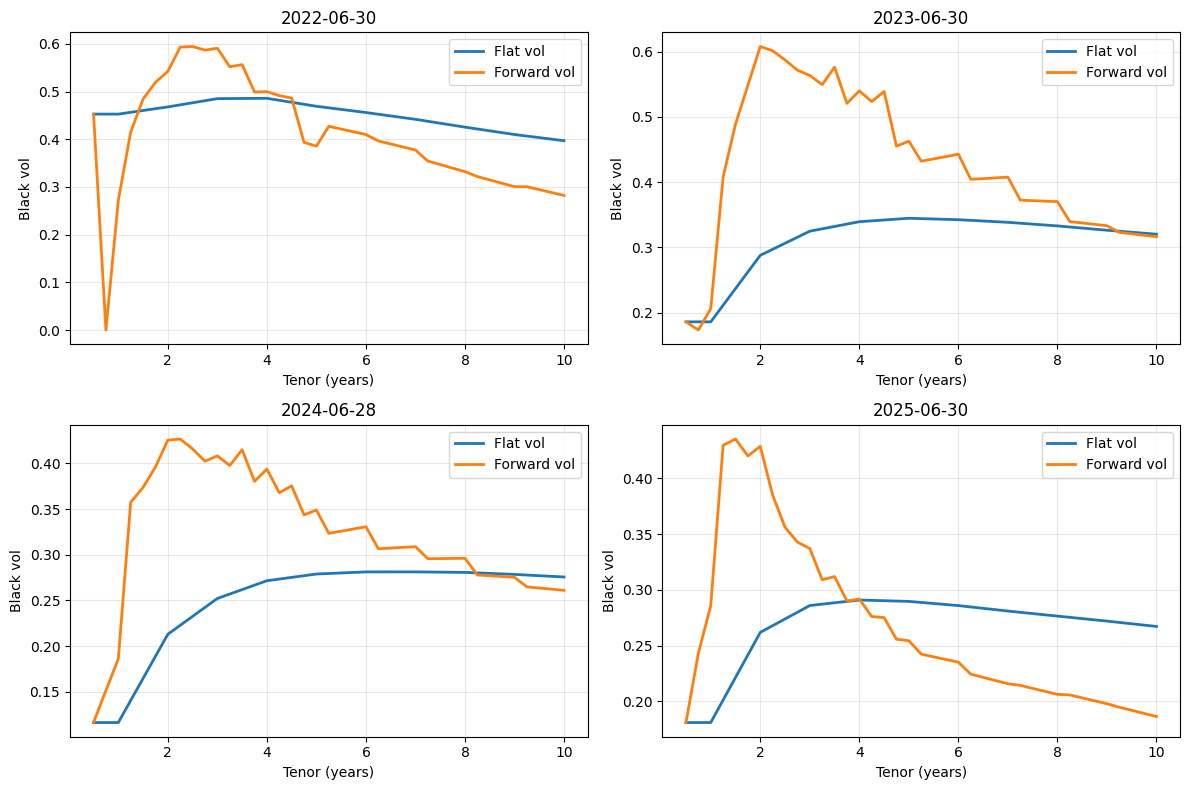

In [240]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, d in zip(axes, q1c_dates):
    curve = q1c_curves[d]
    curve["flat vols"].dropna().plot(ax = ax, linewidth = 2, label = "Flat vol")
    curve["fwd vols"].dropna().plot(ax = ax, linewidth = 2, label = "Forward vol")
    ax.set_title(str(d.date()))
    ax.set_xlabel("Tenor (years)")
    ax.set_ylabel("Black vol")
    ax.grid(True, alpha = 0.3)
    ax.legend()

plt.tight_layout()
plt.show()

### Question 2: Forward Vol Time Series

**Build a panel of forward vols by stripping the cap curve on each date in the time series.**

a) Process each weekly date in the sample (resample the daily data to weekly frequency). For each date, extract forward caplet vols at key tenors: 0.5Y, 1Y, 2Y, 3Y, 5Y. Store these in a panel indexed by date and tenor.

In [241]:
key_tenors = [0.5, 1.0, 2.0, 3.0, 5.0]
cap_weekly = cap_data.resample("W-FRI").last()
sofr_weekly = sofr_data.resample("W-FRI").last()

weekly_dates = cap_weekly.index.intersection(sofr_weekly.index)

panel_rows = []

for d in weekly_dates:
    cap_row = cap_weekly.loc[d].dropna()
    swap_row = sofr_weekly.loc[d].dropna()

    if cap_row.empty or swap_row.empty:
        continue

    curve = strip_forward_vol_curve(
        d,
        cap_data=cap_weekly,
        sofr_data=sofr_weekly,
        quarterly_grid = quarterly_grid,
        delta = delta,
        notional = notional
    )

    for tenor in key_tenors:
        panel_rows.append({
            "date": d,
            "tenor": tenor,
            "fwd_vol": curve.loc[tenor, "fwd vols"]
        })

fwd_panel = (
    pd.DataFrame(panel_rows)
    .dropna()
    .sort_values(["date", "tenor"])
    .reset_index(drop=True)
)

display(fwd_panel)

,date,tenor,fwd_vol
0,2022-03-18,0.5,0.702446
1,2022-03-18,1.0,0.000000
2,2022-03-18,2.0,0.158308
3,2022-03-18,3.0,0.488811
4,2022-03-18,5.0,0.593419
...,...,...,...
990,2026-01-02,0.5,0.148235
991,2026-01-02,1.0,0.207594
992,2026-01-02,2.0,0.253984
993,2026-01-02,3.0,0.218032


In [242]:
fwd_panel_wide = fwd_panel.pivot(index="date", columns="tenor", values="fwd_vol")

display(fwd_panel_wide.head())

tenor,0.5,1.0,2.0,3.0,5.0
date,,,,,
2022-03-18,0.702446,0.0,0.158308,0.488811,0.593419
2022-03-25,0.773270,0.0,0.000000,0.450934,0.512383
2022-04-01,0.488851,0.0,0.354728,0.509208,0.684306
2022-04-08,0.584572,0.0,0.254327,0.454685,0.549329
2022-04-15,0.656684,0.0,0.210657,0.434869,0.487417


b) Plot the forward vol time series at each tenor. Describe the dynamics:
   - Which tenors are most volatile?
   - How did forward vol evolve through the hiking cycle (2022–23), the pause (2023–24), and the easing (2024–25)?

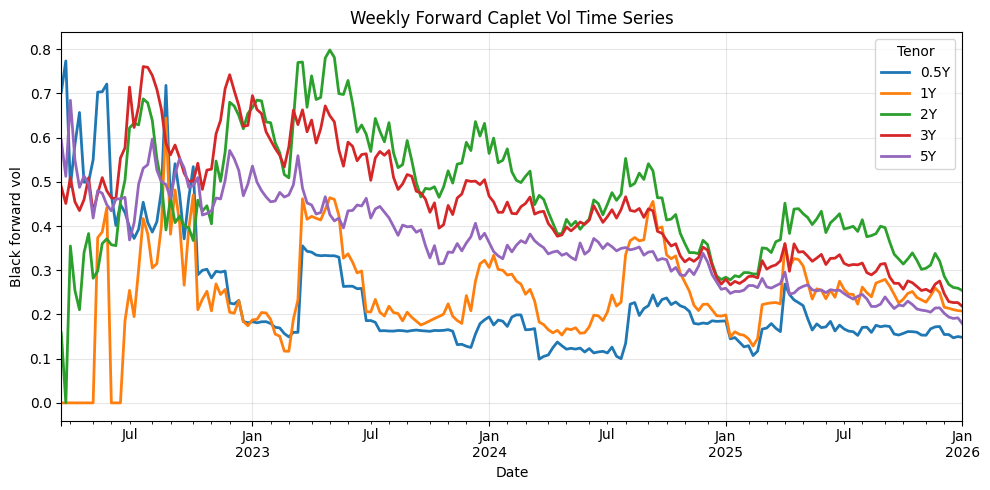

In [243]:
fig, ax = plt.subplots(figsize=(10,5))

for tenor in fwd_panel_wide.columns:
    fwd_panel_wide[tenor].plot(
        ax=ax,
        linewidth=2,
        label=f"{tenor:g}Y"
    )

ax.set_xlabel("Date")
ax.set_ylabel("Black forward vol")
ax.set_title("Weekly Forward Caplet Vol Time Series")
ax.legend(title = "Tenor")
ax.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

The most volatile tenors are the 0.5Y, 2Y and 3Y. The 0.5Y forward vol has the largest spikes earliest in the sample and generally large spikes throughout the sample reflecting market expectations of policy changes or unexpected updates. The 2Y and 3Y have higher forward vol throughout the period reflecting uncertainty about medium term rate changes including their size and frequency. Typically the most volatile should be the 0.5 and 1Y, however, while the 0.5Y is priced on a single caplet, the 1Y is priced using the diff between the 1Y and 0.75Y cap.

Volatility is generally highest during 2022-2023 with high values and sharp increases across all tenors, particularly starting out high for 05 and sharply increasing for 2 and 3Y tenors. Overtime forward vols became more stable, but there were still spikes across all tenors but most sharply in 0.5Y and 1Y. Throughout the easing cycle forward vol continued to decline and the forward vol curve flattened.

c) Report summary statistics (mean, std, min, max) for the forward vol panel. Be sure to discuss whether you are working in Black or normal vol units and why that choice matters for cross-tenor comparisons.

In [244]:
summary_stats = fwd_panel_wide.agg(["mean","std","min","max"]).T

display(summary_stats)

,mean,std,min,max
tenor,,,,
0.5,0.235264,0.137557,0.098893,0.773270
1.0,0.244756,0.103429,0.000000,0.644309
2.0,0.466172,0.136501,0.000000,0.798078
3.0,0.446872,0.132256,0.218032,0.760604
5.0,0.365296,0.103359,0.178894,0.684306


We are working in Black vol units, normal vol was converted to blacks vol before caplet stripping, and Black pricing was used during caplet inversion. Normal distributions are symmetrical and allow negative interest rate, but we are not modeling a rate of return. The choice matters for cross-tenor comparisons because Black's model does not allow negative rates, and allows for forward vols at different maturies to be compared using relative changes in interest rates

### Question 3: Predictive Power of the Forward Vol Curve

**Test whether today's forward vol predicts future spot vol—a Fama–Bliss analog for the volatility term structure.**

*Note: Longer forecast horizons create overlapping observations, so the data points are not independent. Keep this in mind when interpreting $R^2$.*

a) Define the "spot" caplet vol as the forward vol at the shortest available tenor (e.g., 0.5Y). For each forward horizon $\tau$ in your panel, identify the appropriate prediction horizon $h = \tau - \delta$ (where $\delta$ is the spot tenor). Run the predictive regression:

$$\sigma_{\text{spot}}(t{+}h, \delta) = \alpha + \beta \cdot \sigma_{\text{fwd}}(t, \tau) + \varepsilon_t$$

for several forward horizons ($\tau$ = 1Y, 1.5Y, 2Y, 3Y). Use normal vol throughout ($\sigma_N = \sigma_B \times f$).

In [246]:
delta_spot = 0.25
spot_tenor = 0.5
tau_horizons = [1.0, 1.5, 2.0, 3.0]

q3_tenors = [0.5, 1.0, 1.5, 2.0, 3.0]
q3_rows = []
for d in weekly_dates:
    curve = strip_forward_vol_curve(d, cap_data=cap_weekly, sofr_data=sofr_weekly,
                                    quarterly_grid=quarterly_grid, delta=delta, notional=notional)
    for tenor in q3_tenors:
        if tenor not in curve.index:
            continue
        fwd_vol_b = curve.loc[tenor, "fwd vols"]
        fwd_rate = curve.loc[tenor, "forwards"]
        if pd.isna(fwd_vol_b) or pd.isna(fwd_rate) or fwd_rate <= 0:
            continue
        q3_rows.append({"date": d, "tenor": tenor, "fwd_vol_black": fwd_vol_b, "forward_rate": fwd_rate})
q3_df = pd.DataFrame(q3_rows)
q3_df["normal_vol"] = q3_df["fwd_vol_black"] * q3_df["forward_rate"]

In [247]:
nv_wide = q3_df.pivot(index="date", columns="tenor", values="normal_vol").sort_index()
dates = nv_wide.index.tolist()

# Regression: sigma_spot(t+h) = alpha + beta * sigma_fwd(t, tau); h = tau - spot_tenor
from sklearn.linear_model import LinearRegression
results = []
for tau in tau_horizons:
    h_years = tau - spot_tenor
    h_weeks = int(round(h_years * 52))
    y_list, x_list = [], []
    for i, t in enumerate(dates):
        j = i + h_weeks
        if j >= len(dates):
            break
        t_plus_h = dates[j]
        x_list.append(nv_wide.loc[t, tau])
        y_list.append(nv_wide.loc[t_plus_h, spot_tenor])
    x = np.array(x_list).reshape(-1, 1)
    y = np.array(y_list)
    reg = LinearRegression().fit(x, y)
    r2 = reg.score(x, y)
    results.append({"tau": tau, "horizon_years": h_years, "alpha": reg.intercept_, "beta": reg.coef_[0], "R2": r2, "n": len(y)})

q3_results = pd.DataFrame(results)
display(q3_results[["tau", "horizon_years", "alpha", "beta", "R2", "n"]])

,tau,horizon_years,alpha,beta,R2,n
0,1.0,0.5,0.010775,-0.176461,0.046562,173
1,1.5,1.0,0.013845,-0.334755,0.320612,147
2,2.0,1.5,0.008395,-0.054395,0.023807,121
3,3.0,2.5,0.011176,-0.237576,0.191879,69


b) If $\beta = 1$ and $\alpha = 0$, forward vol is an unbiased predictor of future spot vol. Report $\beta$ and $R^2$ for each horizon. Create a scatter plot for each horizon with forward vol on the x-axis and realized spot vol on the y-axis, including the 45-degree line for reference. Interpret the results.

In [248]:
display(q3_results[["tau", "horizon_years", "alpha", "beta", "R2", "n"]])

,tau,horizon_years,alpha,beta,R2,n
0,1.0,0.5,0.010775,-0.176461,0.046562,173
1,1.5,1.0,0.013845,-0.334755,0.320612,147
2,2.0,1.5,0.008395,-0.054395,0.023807,121
3,3.0,2.5,0.011176,-0.237576,0.191879,69


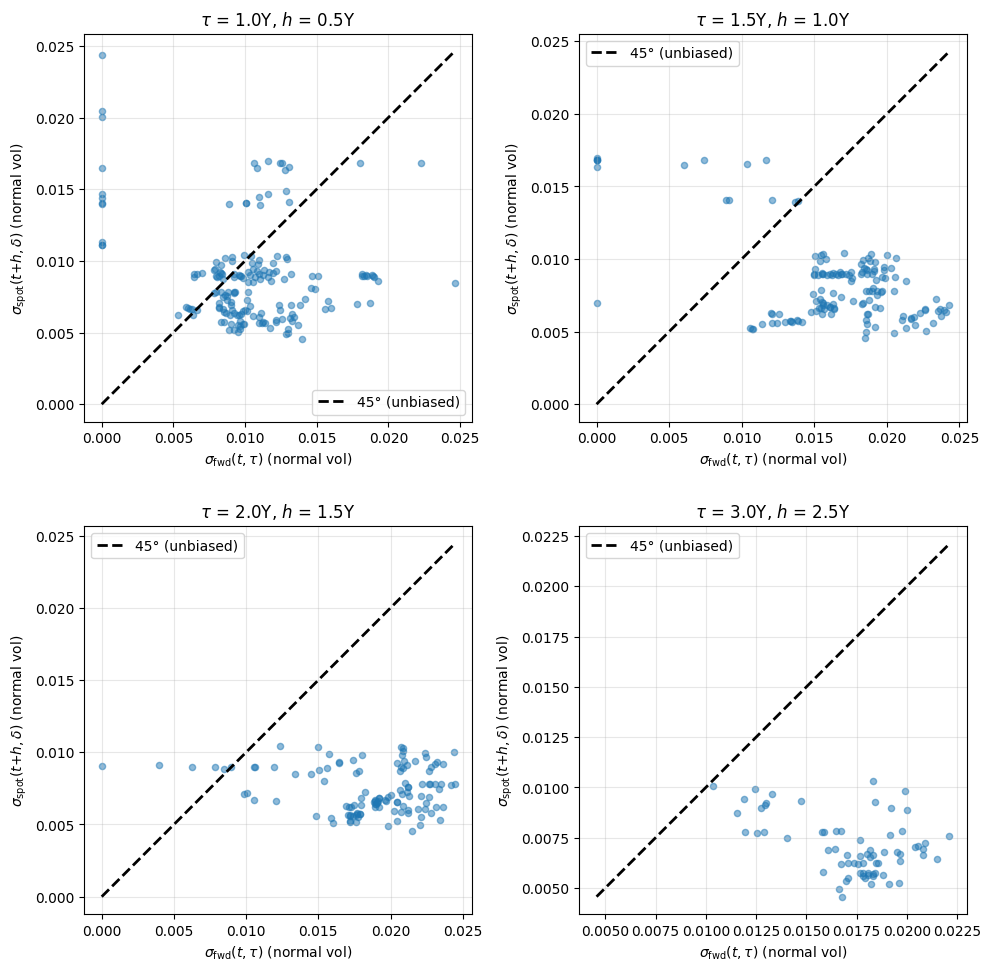

In [249]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()
for idx, tau in enumerate(tau_horizons):
    h_weeks = int(round((tau - spot_tenor) * 52))
    x_vals, y_vals = [], []
    for i, t in enumerate(dates):
        j = i + h_weeks
        if j >= len(dates):
            break
        x_vals.append(nv_wide.loc[t, tau])
        y_vals.append(nv_wide.loc[dates[j], spot_tenor])
    ax = axes[idx]
    ax.scatter(x_vals, y_vals, alpha=0.5, s=20)
    lims = [min(x_vals + y_vals), max(x_vals + y_vals)]
    ax.plot(lims, lims, "k--", lw=2, label="45° (unbiased)")
    ax.set_xlabel(r"$\sigma_{\mathrm{fwd}}(t, \tau)$ (normal vol)")
    ax.set_ylabel(r"$\sigma_{\mathrm{spot}}(t{+}h, \delta)$ (normal vol)")
    ax.set_title(rf"$\tau$ = {tau}Y, $h$ = {tau - spot_tenor}Y")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

Beta is far from 1, it is very low and often negative, while alpha is close to zero. The R2 values are also very low. This implies that forward vol is not a great predictor of future spot vol, further, the beta implies that there is a weak relationship if close to zero, or there is mean reversion if negative.

### Question 4: The Volatility Term Premium

**Characterize the volatility term premium implied by the forward vol curve and assess its reliability across tenors.**

a) Define the **volatility term premium**: $\text{VTP}_t(\tau) = \sigma_{\text{fwd}}(t, \tau) - \sigma_{\text{spot}}(t{+}h, \delta)$. Plot this over time and report what fraction of observations are positive. Does the VTP grow with tenor?

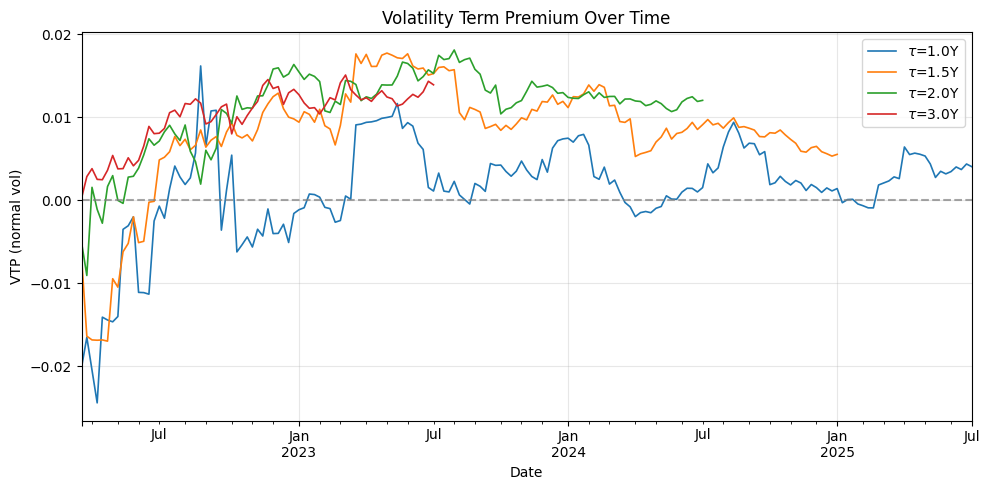

Fraction of observations with VTP > 0:


,frac_positive
tau,
1.0,0.710983
1.5,0.897959
2.0,0.950413
3.0,1.000000


Mean VTP by tenor (does VTP grow with tenor?):


,mean_VTP
tau,
1.0,0.001470
1.5,0.008166
2.0,0.011120
3.0,0.010189


In [250]:
vtp_rows = []
for i, t in enumerate(dates):
    for tau in tau_horizons:
        h_weeks = int(round((tau - spot_tenor) * 52))
        j = i + h_weeks
        if j >= len(dates):
            continue
        sigma_fwd = nv_wide.loc[t, tau]
        sigma_spot = nv_wide.loc[dates[j], spot_tenor]
        vtp_rows.append({"date": t, "tau": tau, "vtp": sigma_fwd - sigma_spot})
vtp_df = pd.DataFrame(vtp_rows)
vtp_wide = vtp_df.pivot(index="date", columns="tau", values="vtp").sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
for tau in tau_horizons:
    vtp_wide[tau].dropna().plot(ax=ax, label=rf"$\tau$={tau}Y", linewidth=1.2)
ax.axhline(0, color="gray", linestyle="--", alpha=0.7)
ax.set_xlabel("Date")
ax.set_ylabel("VTP (normal vol)")
ax.set_title("Volatility Term Premium Over Time")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

frac_positive = vtp_wide.apply(lambda s: s.dropna().gt(0).mean())
mean_vtp = vtp_wide.mean()
print("Fraction of observations with VTP > 0:")
display(frac_positive.to_frame(name="frac_positive"))
print("Mean VTP by tenor (does VTP grow with tenor?):")
display(mean_vtp.to_frame(name="mean_VTP"))

b) For each forward horizon in your panel ($\tau$ = 1Y, 1.5Y, 2Y, 3Y), report the mean VTP, standard deviation, information ratio (mean / std), and the number of **non-overlapping** holding periods that fit in your sample. Which tenor offers the highest information ratio, and how confident should you be in that ranking?

In [251]:
sample_years = (vtp_wide.index.max() - vtp_wide.index.min()).days / 365.25
q4b_list = []
for tau in tau_horizons:
    h_years = tau - spot_tenor
    s = vtp_wide[tau].dropna()
    mean_v = s.mean()
    std_v = s.std()
    ir = mean_v / std_v if std_v > 0 else np.nan
    n_nonoverlap = int(sample_years / h_years) if h_years > 0 else 0
    q4b_list.append({"tau": tau, "mean_VTP": mean_v, "std_VTP": std_v, "IR": ir, "n_nonoverlap": n_nonoverlap})
q4b_table = pd.DataFrame(q4b_list)
display(q4b_table)
best_tau = q4b_table.loc[q4b_table["IR"].idxmax(), "tau"]
print(f"Highest information ratio: τ = {best_tau}Y")

,tau,mean_VTP,std_VTP,IR,n_nonoverlap
0,1.0,0.001470,0.005993,0.245246,6
1,1.5,0.008166,0.006914,1.181147,3
2,2.0,0.011120,0.004895,2.271797,2
3,3.0,0.010189,0.003525,2.890689,1


Highest information ratio: τ = 3.0Y


c) Split your sample in half (e.g., pre- and post-2024). Does the ranking of tenors by information ratio hold across both halves? Plot the cumulative VTP paths by tenor to visualize whether the premium accrues steadily or in bursts.

Pre-2024: mean, std, IR by tenor


,tau,mean,std,IR
0,1.0,0.000366,0.007573,0.048288
1,1.5,0.007883,0.008468,0.930846
2,2.0,0.010860,0.005524,1.965969
3,3.0,0.010189,0.003525,2.890689


Post-2024: mean, std, IR by tenor


,tau,mean,std,IR
0,1.0,0.002783,0.002758,1.009154
1,1.5,0.008669,0.002355,3.680185
2,2.0,0.012023,0.000576,20.865542
3,3.0,NaN,NaN,NaN


Pre-2024  best tenor (by IR): 3.0
Post-2024 best tenor (by IR): 2.0


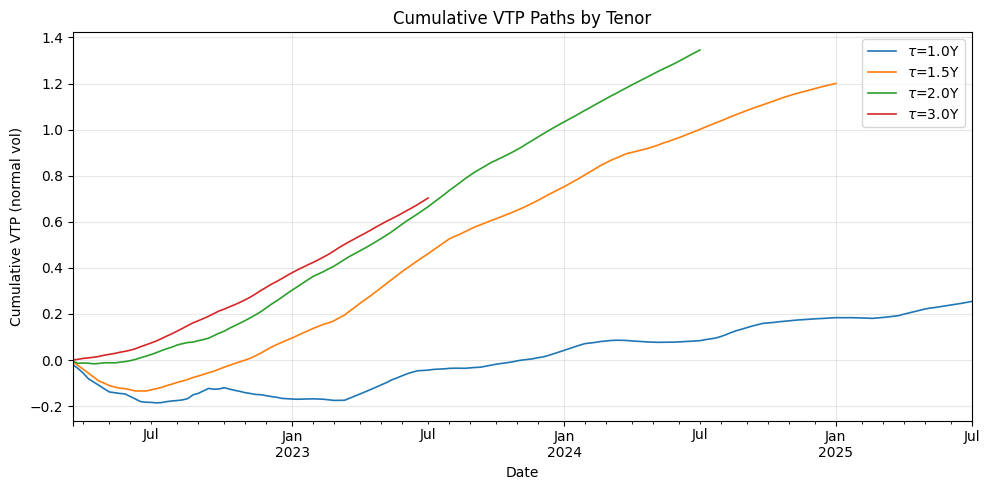

In [252]:
cutoff = pd.Timestamp("2024-01-01")
pre = vtp_wide[vtp_wide.index < cutoff]
post = vtp_wide[vtp_wide.index >= cutoff]

def ir_table(vtp_slice):
    return pd.DataFrame([
        {"tau": tau, "mean": vtp_slice[tau].mean(), "std": vtp_slice[tau].std(),
         "IR": vtp_slice[tau].mean() / vtp_slice[tau].std() if vtp_slice[tau].std() > 0 else np.nan}
        for tau in tau_horizons
    ])

print("Pre-2024: mean, std, IR by tenor")
display(ir_table(pre))
print("Post-2024: mean, std, IR by tenor")
display(ir_table(post))
print("Pre-2024  best tenor (by IR):", ir_table(pre).loc[ir_table(pre)["IR"].idxmax(), "tau"])
print("Post-2024 best tenor (by IR):", ir_table(post).loc[ir_table(post)["IR"].idxmax(), "tau"])

fig, ax = plt.subplots(figsize=(10, 5))
for tau in tau_horizons:
    vtp_wide[tau].dropna().cumsum().plot(ax=ax, label=rf"$\tau$={tau}Y", linewidth=1.2)
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative VTP (normal vol)")
ax.set_title("Cumulative VTP Paths by Tenor")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Question 5: Implied vs. Realized Vol and Carry Strategy

**Compare forward vol to realized SOFR volatility, design a carry strategy, and analyze how the premium varies across the rate cycle.**

a) Compute realized SOFR vol: for each date, calculate the annualized standard deviation of daily SOFR rate changes over the subsequent 3 or 6 months. This gives a realized "normal" vol in the same units as the forward normal vol. Define the **vol risk premium**: $\text{VRP}_t = \sigma_{\text{fwd},t}^{(\tau)} - \sigma_{\text{realized}, t \to t+k}$. Plot the VRP over time and compare it to the VTP from Q4.

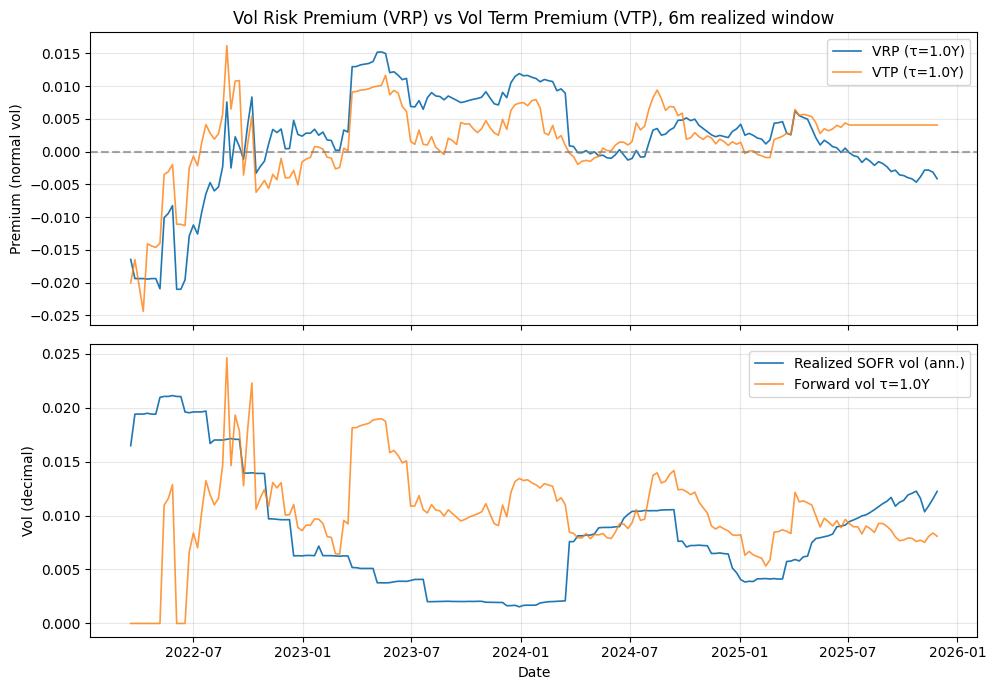

VRP = σ_fwd − σ_realized (same units). VTP = σ_fwd − σ_spot(t+h) from cap curve.


In [253]:
# Q5a: Realized SOFR vol (3m or 6m window), VRP = σ_fwd − σ_realized, plot vs VTP
# Formula: σ_realized,t→t+k = std(Δr_SOFR) × sqrt(252) over daily changes in [t, t+k]

k_months = 6  # 3 or 6 months
# SOFR daily: ensure 1D Series, decimal, timezone-naive index
r = sofr_daily.squeeze().astype(float)
if getattr(r.index, "tz", None) is not None:
    r = r.tz_localize(None)
dr = r.diff().dropna()

# For each weekly date in nv_wide, compute realized vol over next k months
realized_list = []
for t in nv_wide.index:
    t_naive = pd.Timestamp(t).tz_localize(None) if getattr(t, "tz", None) else pd.Timestamp(t)
    t_end = t_naive + pd.DateOffset(months=k_months)
    end = min(t_end, dr.index.max())
    w = dr[(dr.index >= t_naive) & (dr.index <= end)]
    if len(w) < 20:
        continue
    sig = float(w.std() * np.sqrt(252))
    realized_list.append((t_naive, sig))
realized_series = pd.Series([x[1] for x in realized_list], index=pd.DatetimeIndex([x[0] for x in realized_list]))

# Pick tenor present in both nv_wide and vtp_wide
tau_vrp = 1.0
if tau_vrp not in nv_wide.columns or tau_vrp not in vtp_wide.columns:
    tau_vrp = [c for c in [1.0, 1.5, 2.0, 3.0] if c in nv_wide.columns and c in vtp_wide.columns][0]

# Align: use only dates in realized_series; ensure index types match for reindex
ix = realized_series.index
# Normalize to naive datetime so reindex finds matches (avoid blank plot)
nv_flat = nv_wide[tau_vrp].copy()
vtp_flat = vtp_wide[tau_vrp].copy()
if getattr(nv_flat.index, "tz", None) is not None:
    nv_flat = nv_flat.tz_localize(None)
if getattr(vtp_flat.index, "tz", None) is not None:
    vtp_flat = vtp_flat.tz_localize(None)
sigma_fwd = nv_flat.reindex(ix).ffill().bfill()
sigma_real = realized_series.reindex(ix).ffill().bfill()
vrp_series = sigma_fwd.astype(float) - sigma_real
vtp_1y = vtp_flat.reindex(ix).ffill().bfill()

# Drop rows where any key series is NaN so both plots have valid data
valid = vrp_series.notna() & vtp_1y.notna() & sigma_fwd.notna() & sigma_real.notna()
ix_valid = ix[valid]
if len(ix_valid) == 0:
    raise ValueError("No valid aligned dates: check nv_wide, vtp_wide, and sofr_daily index alignment.")
vrp_v = vrp_series.loc[ix_valid]
vtp_v = vtp_1y.loc[ix_valid]
fwd_v = sigma_fwd.loc[ix_valid]
real_v = sigma_real.loc[ix_valid]

# Plot 1: VRP vs VTP over time
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
ax = axes[0]
ax.plot(ix_valid, vrp_v.values, label=f"VRP (τ={tau_vrp}Y)", linewidth=1.2)
ax.plot(ix_valid, vtp_v.values, label=f"VTP (τ={tau_vrp}Y)", linewidth=1.2, alpha=0.8)
ax.axhline(0, color="gray", linestyle="--", alpha=0.7)
ax.set_ylabel("Premium (normal vol)")
ax.set_title(f"Vol Risk Premium (VRP) vs Vol Term Premium (VTP), {k_months}m realized window")
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Realized vol vs forward vol (same aligned index)
ax = axes[1]
ax.plot(ix_valid, real_v.values, label="Realized SOFR vol (ann.)", linewidth=1.2)
ax.plot(ix_valid, fwd_v.values, label=f"Forward vol τ={tau_vrp}Y", linewidth=1.2, alpha=0.8)
ax.set_ylabel("Vol (decimal)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("VRP = σ_fwd − σ_realized (same units). VTP = σ_fwd − σ_spot(t+h) from cap curve.")

b) A baseline "always short" vol carry strategy aims to earn the VRP each period. Compute its cumulative P&L (in vol units) and hit rate. Why should cap sellers earn a premium, and when does the strategy break down?

c) Classify the sample into three regimes: **Hiking** (March 2022 – July 2023), **Pause** (August 2023 – August 2024), and **Easing** (September 2024 – December 2025). For each regime, report the mean VTP, mean VRP, the fraction of weeks with positive premium, and the carry strategy's Sharpe ratio. Visualize the premium distributions across regimes. Interpret the variation.

### Question 6: Harvesting the Vol Premium in Practice

**Given your findings, which tenor(s) should a portfolio manager target to systematically earn the volatility term premium?**

a) Consider transaction costs. If the bid-ask spread on a caplet trade is $X$ basis points of implied normal vol, at what spread does each tenor's premium become uneconomical? Compute the breakeven bid-ask spread for each tenor. Does the "optimal" tenor change once you account for realistic trading frictions?

   *Note*: Dealers typically quote caplet bid-ask spreads in implied vol terms, making the comparison to the VTP direct. If instead costs are quoted in price terms (bp of notional), converting to vol space requires dividing by the caplet's vega—the sensitivity of price to a 1 bp change in implied vol.

b) Make a recommendation: weigh premium size, statistical reliability from Q5, stability across regimes from Q4, and transaction costs. Is there a single best tenor, or does the answer depend on assumptions? What would you monitor to update this recommendation going forward?

### Summary

### AI Usage Statement

## Deliverables

Review the [Project Guidelines](https://markhendricks.github.io/finm-fixedincome/discussions/11.0.%20Project%20Guidelines_copy.html) for submission standards, conciseness expectations, and AI usage policy.

Submit a Jupyter notebook with analysis for all six questions (Q1–Q6), including code, figures, and written interpretation. Include a summary section (1–2 paragraphs) synthesizing your findings: Is the forward vol curve an unbiased predictor of future spot vol? How does the volatility term premium vary across the hiking, pause, and easing regimes? Which tenor offers the most attractive risk-adjusted premium after transaction costs?

**Conciseness is a graded criterion** — see [Project Guidelines](https://markhendricks.github.io/finm-fixedincome/discussions/11.0.%20Project%20Guidelines_copy.html).